# Laser Step-Down: Stability & Per-Step Noise Snapshots
**Scenario:** same ~4-day laser step-down run as `laser_stepdown_settling.ipynb`
(2026-07-05 to 2026-07-09). That notebook detected each held power level from the PD
trace and fit the YAW spin-frequency settling at each transition, saving the step
table to `laser_stepdown_steps.csv`. This notebook picks up from there and focuses on
the **PD (laser monitor) channel** itself:

1. Long-term PD trend across the full run, with the detected steps overlaid.
2. Per-step statistics and Allan deviation -- is the laser noisier/quieter at some
   power levels than others?
3. A PSD "snapshot" at each steady state (last 2 h of each plateau, full 1024 Hz
   bandwidth) -- low- and high-frequency noise at each operating point, overlaid for
   comparison.

No ambient-temperature log covers this date range (unlike `laser_stability.ipynb`'s
May run), so there's no temperature-correlation section here.

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
from scipy.signal import welch
import csv

/Users/mollywatts/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
GPS_UNIX_OFFSET = 315964800 - 18

def gps_to_dt(gps):
    return datetime.fromtimestamp(gps + GPS_UNIX_OFFSET, tz=timezone.utc)

PD_FILES = [
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467323190_1467582390.h5',
    '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/TFINER/data/PD/Y1_RDS-PD_IN1_DQ_1467582390_1467662710.h5',
]
STEP_TABLE_CSV = '/Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_stepdown_steps.csv'

# Loaded from laser_stepdown_settling.ipynb's output -- step boundaries, counts/mW
# (from the operator's step-down log, matched by held-duration) and (where fit) the
# settling tau. Re-detecting steps here would just duplicate that notebook's Section 2;
# reading its saved table keeps the two notebooks in sync.
steps = []
with open(STEP_TABLE_CSV) as f:
    for row in csv.DictReader(f):
        steps.append(dict(
            step=int(row['step']),
            pd_level=float(row['pd_level']),
            counts=float(row['counts']) if row['counts'] else None,
            power_mw=float(row['power_mw']) if row['power_mw'] else None,
            t_start_gps=float(row['t_start_gps']),
            t_end_gps=float(row['t_end_gps']),
            duration_h=float(row['duration_h']),
            tau_s=float(row['tau_s']) if row['tau_s'] else None,
        ))

def step_label(s):
    if s['counts'] is not None:
        return f"{s['counts']:.0f} counts (~{s['power_mw']:.2f} mW)"
    if s['step'] <= 1:
        return f"PD={s['pd_level']:.0f} (pre-sequence)"
    return f"PD={s['pd_level']:.0f} (unmatched sub-step)"

print(f"{len(steps)} steps loaded from {STEP_TABLE_CSV}:")
for s in steps:
    print(f"  [{s['step']}] {step_label(s):26s} {gps_to_dt(s['t_start_gps'])} -> "
          f"{gps_to_dt(s['t_end_gps'])}  ({s['duration_h']:.1f} h)")

colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))

15 steps loaded from /Users/mollywatts/Desktop/VSCode/decay_sail/analysis/laser_stepdown_steps.csv:
  [0] PD=14 (pre-sequence)       2026-07-05 21:46:12+00:00 -> 2026-07-06 18:36:12+00:00  (20.8 h)
  [1] PD=14 (pre-sequence)       2026-07-06 18:51:12+00:00 -> 2026-07-06 19:56:12+00:00  (1.1 h)
  [2] 1800 counts (~15.10 mW)    2026-07-06 20:01:12+00:00 -> 2026-07-06 20:41:12+00:00  (0.7 h)
  [3] 1600 counts (~12.92 mW)    2026-07-06 20:51:12+00:00 -> 2026-07-07 16:41:12+00:00  (19.8 h)
  [4] 1550 counts (~12.23 mW)    2026-07-07 16:46:12+00:00 -> 2026-07-07 19:16:12+00:00  (2.5 h)
  [5] 1500 counts (~11.46 mW)    2026-07-07 19:21:12+00:00 -> 2026-07-07 20:31:12+00:00  (1.2 h)
  [6] 1400 counts (~10.01 mW)    2026-07-07 20:36:12+00:00 -> 2026-07-07 22:01:12+00:00  (1.4 h)
  [7] 1300 counts (~8.49 mW)     2026-07-07 22:06:12+00:00 -> 2026-07-08 16:06:12+00:00  (18.0 h)
  [8] 1200 counts (~7.09 mW)     2026-07-08 16:11:12+00:00 -> 2026-07-08 18:21:12+00:00  (2.2 h)
  [9] PD=74 (unmatched s

## 1. Long-Term PD Trend (Full Span)
Same 1 Hz strided read as `laser_stepdown_settling.ipynb`'s overview, with the
detected steps shaded for reference.

PD: 339,520 points  2026-07-05 21:46:12+00:00 -> 2026-07-09 20:04:51+00:00


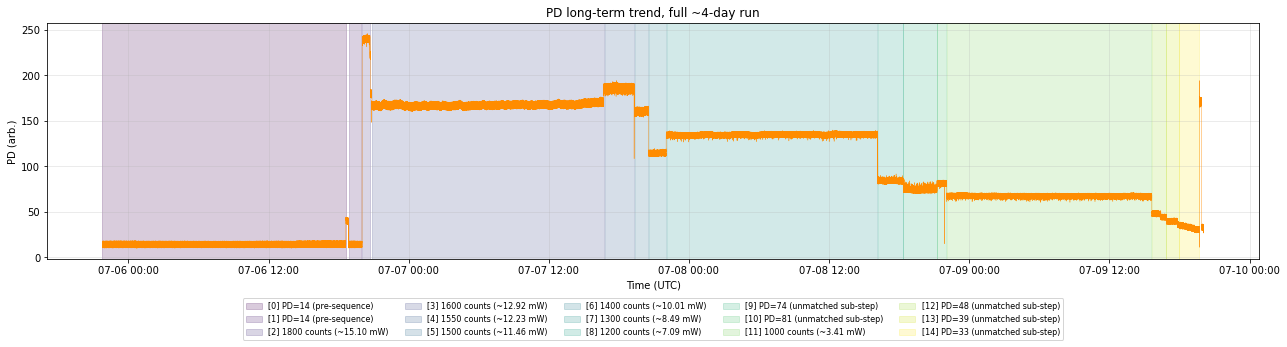

In [3]:
def load_strided_multi(files, stride):
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            for gps0, ix, n in zip(segs, idxs, lens):
                y_seg = dset[ix: ix + n: stride].astype(np.float32)
                t_seg = gps0 + np.arange(len(y_seg)) * stride / fs
                t_list.append(t_seg)
                y_list.append(y_seg)
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

t_pd, y_pd = load_strided_multi(PD_FILES, stride=1024)  # 1 Hz effective
print(f"PD: {len(y_pd):,} points  {gps_to_dt(t_pd[0])} -> {gps_to_dt(t_pd[-1])}")

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot([gps_to_dt(t) for t in t_pd], y_pd, linewidth=0.4, color='darkorange')
for i, s in enumerate(steps):
    ax.axvspan(gps_to_dt(s['t_start_gps']), gps_to_dt(s['t_end_gps']),
               color=colors[i], alpha=0.2, label=f"[{s['step']}] {step_label(s)}")
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('PD (arb.)')
ax.set_title('PD long-term trend, full ~4-day run')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
ax.legend(fontsize=8, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.15))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Per-Step Statistics & Allan Deviation
Allan deviation computed independently *within* each plateau (not across the whole
run) -- combining plateaus would let the big power steps themselves dominate the
long-tau end of the curve, masking the laser's actual noise at each operating point.
Using the 1 Hz trend data from Section 1: enough to characterize drift out to
~hours, which is the regime step-to-step comparison is about (sub-second noise is
covered by the PSD snapshots in Section 3 instead).

step 0 (PD=14 (pre-sequence)): mean=  14.10  std=2.2796  RIN=16.170%
step 1 (PD=14 (pre-sequence)): mean=  14.10  std=2.2698  RIN=16.099%
step 2 (1800 counts (~15.10 mW)): mean= 239.79  std=2.7682  RIN=1.154%
step 3 (1600 counts (~12.92 mW)): mean= 167.37  std=2.9791  RIN=1.780%
step 4 (1550 counts (~12.23 mW)): mean= 186.24  std=2.9506  RIN=1.584%
step 5 (1500 counts (~11.46 mW)): mean= 160.25  std=2.4168  RIN=1.508%
step 6 (1400 counts (~10.01 mW)): mean= 114.53  std=1.9561  RIN=1.708%
step 7 (1300 counts (~8.49 mW)): mean= 134.58  std=1.9368  RIN=1.439%
step 8 (1200 counts (~7.09 mW)): mean=  84.15  std=1.7570  RIN=2.088%
step 9 (PD=74 (unmatched sub-step)): mean=  74.44  std=2.5904  RIN=3.480%
step 10 (PD=81 (unmatched sub-step)): mean=  81.25  std=2.2747  RIN=2.800%
step 11 (1000 counts (~3.41 mW)): mean=  67.20  std=1.5620  RIN=2.325%
step 12 (PD=48 (unmatched sub-step)): mean=  46.34  std=2.4408  RIN=5.267%
step 13 (PD=39 (unmatched sub-step)): mean=  39.34  std=2.3500  RIN=5.97

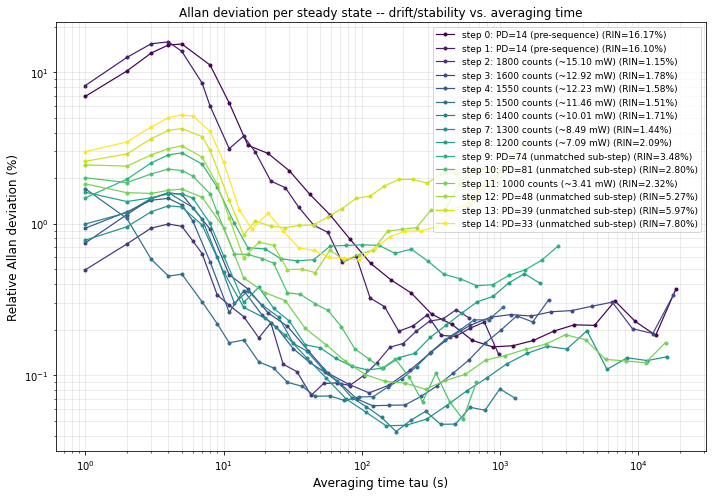

In [4]:
def allan_dev(x, fs, n_tau=30):
    taus, adevs = [], []
    max_m = len(x) // 4
    for m in np.unique(np.round(np.logspace(0, np.log10(max_m), n_tau)).astype(int)):
        n = len(x) // m
        if n < 2:
            continue
        yb = x[:n * m].reshape(n, m).mean(axis=1)
        adevs.append(np.sqrt(0.5 * np.mean(np.diff(yb) ** 2)))
        taus.append(m / fs)
    return np.array(taus), np.array(adevs)

step_stats = []
fig, ax = plt.subplots(figsize=(10, 7))
for i, s in enumerate(steps):
    m = (t_pd >= s['t_start_gps']) & (t_pd <= s['t_end_gps'])
    y_step = y_pd[m]
    mean, std = y_step.mean(), y_step.std()
    rin = std / abs(mean) * 100
    taus, adevs = allan_dev(y_step, fs=1.0)
    rel_adevs = adevs / abs(mean) * 100

    ax.loglog(taus, rel_adevs, 'o-', color=colors[i], markersize=3, linewidth=1.2,
              label=f"step {s['step']}: {step_label(s)} (RIN={rin:.2f}%)")

    step_stats.append(dict(step=s['step'], pd_level=s['pd_level'], mean=mean, std=std,
                            rin=rin, taus=taus, rel_adevs=rel_adevs))
    print(f"step {s['step']} ({step_label(s)}): mean={mean:7.2f}  std={std:.4f}  RIN={rin:.3f}%")

ax.set_xlabel('Averaging time tau (s)', fontsize=12)
ax.set_ylabel('Relative Allan deviation (%)', fontsize=12)
ax.set_title('Allan deviation per steady state -- drift/stability vs. averaging time')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Per-Step PSD Snapshots (Full Bandwidth)
For each steady state, load the **last 2 hours** of that plateau directly from the
raw 1024 Hz data (targeted read -- only that window, not the whole file) so both the
low-frequency drift and the high-frequency noise floor (up to the 512 Hz Nyquist) are
visible. Using the last 2 h (rather than the whole plateau) keeps every step's
snapshot the same duration/frequency-resolution and guarantees it's taken well after
the settling transient from `laser_stepdown_settling.ipynb`.

In [5]:
SNAPSHOT_HOURS = 2.0

def load_raw_window(files, gps_t0, gps_t1):
    """Targeted raw (undecimated) read restricted to [gps_t0, gps_t1] -- cheap even
    at 1024 Hz since only a couple of hours are pulled, not the whole multi-day file."""
    t_list, y_list = [], []
    for path in files:
        with h5py.File(path, 'r') as f:
            fs   = float(f.attrs['sample_rate'])
            segs = f['segments/gps_start'][:].astype(np.float64)
            idxs = f['segments/index_start'][:].astype(np.int64)
            lens = f['segments/length'][:].astype(np.int64)
            dset = f['data']
            for gps0, ix, n in zip(segs, idxs, lens):
                gps1 = gps0 + n / fs
                if gps1 < gps_t0 or gps0 > gps_t1:
                    continue
                seg = dset[ix:ix + n].astype(np.float64)
                t_seg = gps0 + np.arange(len(seg)) / fs
                mask = (t_seg >= gps_t0) & (t_seg <= gps_t1)
                t_list.append(t_seg[mask])
                y_list.append(seg[mask])
    if not t_list:
        return np.array([]), np.array([])
    t = np.concatenate(t_list); y = np.concatenate(y_list)
    order = np.argsort(t)
    return t[order], y[order]

psd_results = []
for i, s in enumerate(steps):
    t_end = s['t_end_gps']
    t_start = t_end - SNAPSHOT_HOURS * 3600
    t_win, y_win = load_raw_window(PD_FILES, t_start, t_end)
    fs = 1024.0
    freqs, psd = welch(y_win, fs=fs, nperseg=int(fs * 10), scaling='density')
    asd = np.sqrt(psd)
    psd_results.append(dict(step=s['step'], pd_level=s['pd_level'], freqs=freqs, asd=asd,
                             mean=y_win.mean()))
    print(f"step {s['step']} ({step_label(s)}): {len(y_win):,} samples "
          f"({gps_to_dt(t_start).strftime('%m-%d %H:%M')} -> {gps_to_dt(t_end).strftime('%H:%M')})")

step 0 (PD=14 (pre-sequence)): 7,372,801 samples (07-06 16:36 -> 18:36)
step 1 (PD=14 (pre-sequence)): 7,372,801 samples (07-06 17:56 -> 19:56)
step 2 (1800 counts (~15.10 mW)): 7,372,801 samples (07-06 18:41 -> 20:41)
step 3 (1600 counts (~12.92 mW)): 7,372,801 samples (07-07 14:41 -> 16:41)
step 4 (1550 counts (~12.23 mW)): 7,372,801 samples (07-07 17:16 -> 19:16)
step 5 (1500 counts (~11.46 mW)): 7,372,801 samples (07-07 18:31 -> 20:31)
step 6 (1400 counts (~10.01 mW)): 7,372,801 samples (07-07 20:01 -> 22:01)
step 7 (1300 counts (~8.49 mW)): 7,372,801 samples (07-08 14:06 -> 16:06)
step 8 (1200 counts (~7.09 mW)): 7,372,801 samples (07-08 16:21 -> 18:21)
step 9 (PD=74 (unmatched sub-step)): 7,372,801 samples (07-08 19:16 -> 21:16)
step 10 (PD=81 (unmatched sub-step)): 7,372,801 samples (07-08 20:01 -> 22:01)
step 11 (1000 counts (~3.41 mW)): 7,372,801 samples (07-09 13:36 -> 15:36)
step 12 (PD=48 (unmatched sub-step)): 7,372,801 samples (07-09 14:51 -> 16:51)
step 13 (PD=39 (unmatc

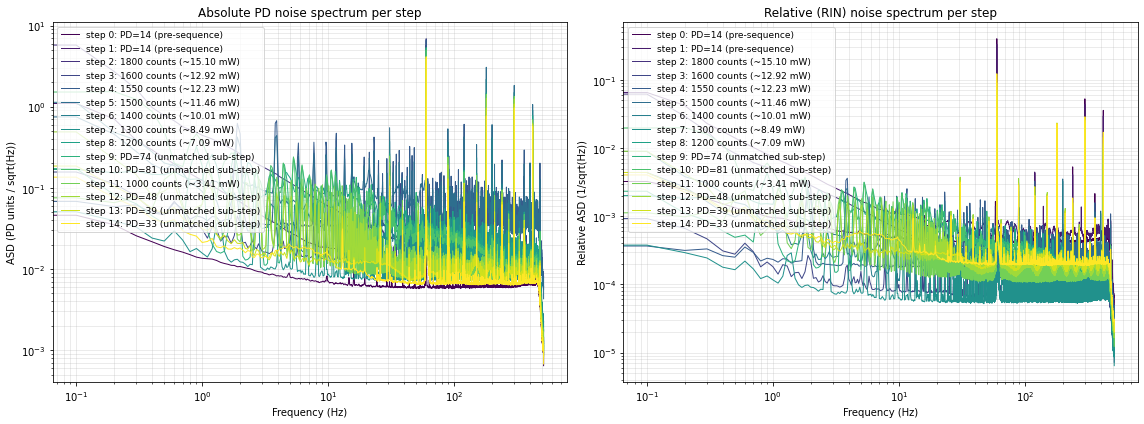

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
steps_by_i = {s['step']: s for s in steps}

for i, r in enumerate(psd_results):
    label = f"step {r['step']}: {step_label(steps_by_i[r['step']])}"
    axes[0].loglog(r['freqs'], r['asd'], color=colors[i], linewidth=1.0, label=label)
    # Relative ASD (normalized by each step's own mean) -- lets you compare noise
    # *fraction* across very different power levels on one scale
    axes[1].loglog(r['freqs'], r['asd'] / abs(r['mean']), color=colors[i], linewidth=1.0, label=label)

axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('ASD (PD units / sqrt(Hz))')
axes[0].set_title('Absolute PD noise spectrum per step')
axes[0].legend(fontsize=9); axes[0].grid(True, which='both', alpha=0.3)

axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Relative ASD (1/sqrt(Hz))')
axes[1].set_title('Relative (RIN) noise spectrum per step')
axes[1].legend(fontsize=9); axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Results Summary
Band-limited RIN (DC-1 Hz, 1-10 Hz, 10-100 Hz, 100-512 Hz) from each step's PSD
snapshot, alongside the Allan-deviation-based drift numbers from Section 2.

In [7]:
BANDS = [(0, 1, 'DC-1 Hz'), (1, 10, '1-10 Hz'), (10, 100, '10-100 Hz'), (100, 512, '100-512 Hz')]
steps_by_i = {s['step']: s for s in steps}

print("=" * 90)
print("LASER STEP-DOWN STABILITY SUMMARY")
print("=" * 90)
for r, st in zip(psd_results, step_stats):
    print(f"\nStep {r['step']} ({step_label(steps_by_i[r['step']])}, mean={st['mean']:.2f}, "
          f"overall RIN={st['rin']:.3f}%):")
    df = r['freqs'][1] - r['freqs'][0]
    for f_lo, f_hi, label in BANDS:
        m = (r['freqs'] >= f_lo) & (r['freqs'] < f_hi)
        band_rin = np.sqrt(np.sum(r['asd'][m] ** 2) * df) / abs(r['mean']) * 100
        print(f"    {label:>10}: RIN = {band_rin:.4f} %")
    print(f"    Allan dev @ tau=1s:  {st['rel_adevs'][0]:.4f} %   "
          f"@ tau={st['taus'][-1]:.0f}s: {st['rel_adevs'][-1]:.4f} %")

LASER STEP-DOWN STABILITY SUMMARY

Step 0 (PD=14 (pre-sequence), mean=14.10, overall RIN=16.170%):
       DC-1 Hz: RIN = 0.1752 %
       1-10 Hz: RIN = 0.1802 %
     10-100 Hz: RIN = 15.8385 %
    100-512 Hz: RIN = 3.5262 %
    Allan dev @ tau=1s:  6.9201 %   @ tau=18750s: 0.3726 %

Step 1 (PD=14 (pre-sequence), mean=14.10, overall RIN=16.099%):
       DC-1 Hz: RIN = 2.7732 %
       1-10 Hz: RIN = 0.7754 %
     10-100 Hz: RIN = 13.1817 %
    100-512 Hz: RIN = 3.2365 %
    Allan dev @ tau=1s:  8.1594 %   @ tau=975s: 0.1381 %

Step 2 (1800 counts (~15.10 mW), mean=239.79, overall RIN=1.154%):
       DC-1 Hz: RIN = 2.5394 %
       1-10 Hz: RIN = 0.5435 %
     10-100 Hz: RIN = 2.4240 %
    100-512 Hz: RIN = 0.6007 %
    Allan dev @ tau=1s:  0.4961 %   @ tau=600s: 0.2386 %

Step 3 (1600 counts (~12.92 mW), mean=167.37, overall RIN=1.780%):
       DC-1 Hz: RIN = 0.0455 %
       1-10 Hz: RIN = 0.0349 %
     10-100 Hz: RIN = 1.6410 %
    100-512 Hz: RIN = 0.3901 %
    Allan dev @ tau=1s:  0.74